In [49]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from sklearn.feature_selection import f_classif, chi2
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import os

In [30]:
# Getting only X_train and analysing it and applying all changes to X_test also
# This is done to prevent Data Leakage

X_train = pd.read_csv(r'C:\Irrigation_Water_Requirement\Data\engineered_Data\X_train.csv')
X_test = pd.read_csv(r'C:\Irrigation_Water_Requirement\Data\engineered_Data\X_test.csv')
y_train = pd.read_csv(r'C:\Irrigation_Water_Requirement\Data\engineered_Data\y_train.csv')
X_train.head()

,num__Soil_pH,num__Soil_Moisture,num__Organic_Carbon,num__Electrical_Conductivity,num__Temperature_C,num__Humidity,num__Rainfall_mm,num__Sunlight_Hours,cat__Soil_Type,cat__Wind_Speed_kmh,...,cat__Irrigation_Type,cat__Water_Source,cat__Field_Area_hectare,cat__Mulching_Used,cat__Previous_Irrigation_mm,cat__Region,Total_Water,Evaporation,Soil_Fertility,Heat_Stress
0,7.58,54.78,0.71,3.23,20.88,39.91,323.92,10.29,Sandy,8.76,...,Drip,River,2.71,Yes,50.3,East,378.70,214.8552,0.155163,6.726618
1,5.90,51.50,0.85,0.67,15.62,45.04,1448.12,7.81,Silt,4.84,...,Rainfed,Reservoir,8.86,Yes,14.5,West,1499.62,121.9922,0.411435,6.557524
2,5.98,41.48,0.31,0.67,18.34,72.45,1608.98,10.94,Loamy,16.23,...,Canal,Reservoir,1.24,Yes,117.32,Central,1650.46,200.6396,0.170273,7.192733
3,6.70,57.59,0.77,0.24,18.63,56.60,1206.63,6.52,Sandy,14.41,...,Rainfed,Groundwater,14.95,No,99.69,South,1264.22,121.4676,0.483023,6.961730
4,4.87,28.53,1.59,2.24,38.10,64.69,2086.72,9.39,Loamy,15.02,...,Sprinkler,River,12.98,No,100.39,East,2115.25,357.7590,0.399273,7.810227


In [4]:
X_train.info()
# As we see this is already engineered set, so some columns are defined according to encoding

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13980 entries, 0 to 13979
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num__Soil_pH                  13980 non-null  float64
 1   num__Soil_Moisture            13980 non-null  float64
 2   num__Organic_Carbon           13980 non-null  float64
 3   num__Electrical_Conductivity  13980 non-null  float64
 4   num__Temperature_C            13980 non-null  float64
 5   num__Humidity                 13980 non-null  float64
 6   num__Rainfall_mm              13980 non-null  float64
 7   num__Sunlight_Hours           13980 non-null  float64
 8   cat__Soil_Type                13980 non-null  object 
 9   cat__Wind_Speed_kmh           13980 non-null  object 
 10  cat__Crop_Type                13980 non-null  object 
 11  cat__Crop_Growth_Stage        13980 non-null  object 
 12  cat__Season                   13980 non-null  object 
 13  c

In [5]:
y_train.sample(10)

,Irrigation_Need
5814,2.0
12686,2.0
13195,2.0
8849,0.0
3975,1.0
12905,2.0
5379,2.0
6846,2.0
10083,0.0
10097,0.0


## Pearson Correlation for numerical features

In [6]:
num_features = X_train.select_dtypes(include=[np.number]).columns
pearson = X_train[num_features].corrwith(y_train.squeeze(), method='pearson').sort_values(ascending=False)
print(f'Pearon Correlation:\n{pearson}')

Pearon Correlation:
num__Soil_Moisture              0.287947
Total_Water                     0.247949
num__Rainfall_mm                0.242382
num__Humidity                   0.069333
Soil_Fertility                  0.025854
num__Organic_Carbon             0.005943
num__Sunlight_Hours            -0.009379
num__Electrical_Conductivity   -0.016009
num__Soil_pH                   -0.030263
Heat_Stress                    -0.083172
Evaporation                    -0.152415
num__Temperature_C             -0.211748
dtype: float64


## Chi-square (χ²)

In [ ]:
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns
encoder = OrdinalEncoder()
X_cat_encoded = encoder.fit_transform(X_train[cat_cols])

chi_scores, p_values = chi2(X_cat_encoded, y_train)

chi_series = pd.Series(chi_scores, index=cat_cols)
print(chi_series.sort_values(ascending=False))

cat__Wind_Speed_kmh            217514.593046
cat__Previous_Irrigation_mm      1706.161435
cat__Field_Area_hectare           734.721306
cat__Mulching_Used                259.057097
cat__Water_Source                  60.848091
cat__Region                         8.692000
cat__Irrigation_Type                7.080249
cat__Season                         3.794604
cat__Crop_Type                      2.629466
cat__Soil_Type                      0.908386
cat__Crop_Growth_Stage              0.255382
dtype: float64


# Input vs Input correlation

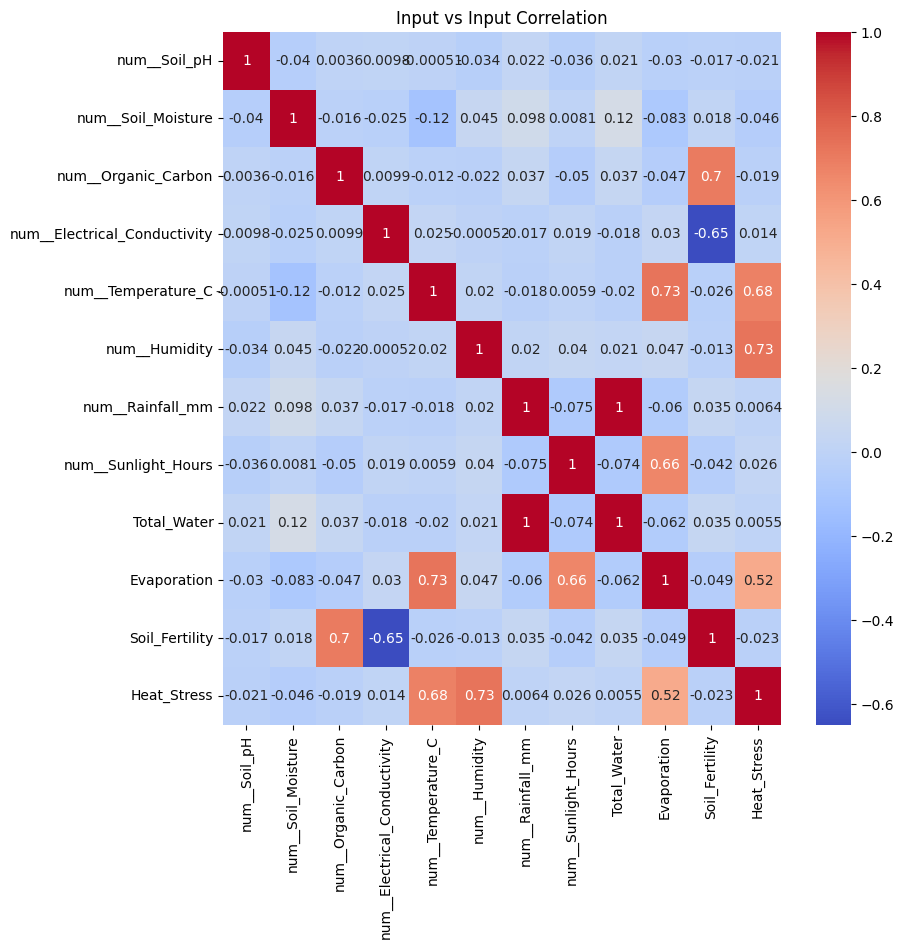

In [10]:
plt.figure(figsize=(9, 9))
sns.heatmap(X_train[num_features].corr(), annot=True, cmap='coolwarm')
plt.title('Input vs Input Correlation')
plt.show()

In [ ]:
corr_marix = X_train[num_features].corr()

fig = px.imshow(
    corr_matrix, 
    text_auto=True,
    color_continuous_scale='RdBu_r',
    origin='upper',
    labels=dict(x = 'Features', y = 'Features', color = 'Correlation'),
    title='Feagure to Feagure Correlation (Plotly Express)'
)
fig.update_xaxes(side = 'top')
fig.show()

In [26]:
corr_matrix = X_train[num_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# np.ones => creates array with the shape of corr_matrix
# np.trui => traingle upper, k = 1 => selected the upper from the main diagonal
to_drop = [column for column in upper.columns if any(upper[column] > 0.70)]
print("Highly correlated features to drop:", to_drop)

Highly correlated features to drop: ['Total_Water', 'Evaporation', 'Heat_Stress']


As we have seen theese features, and aslo seen the pearson, Evoporation, Heat_Stress and Total Water features are highly corroleated to some other features so, we need to drop them out. 

In [31]:
X_train_dropped = X_train.drop(to_drop, axis=1)
X_test_dropped = X_test.drop(to_drop, axis=1)

## Feature sellection for model

In [ ]:
hot_enc = OneHotEncoder()
std_scalar = StandardScaler()

for col in X_train_dropped.columns:
    if X_train_dropped[col].dtype == "object":
        X_train_dropped[col] = encoder.fit_transform(X_train_dropped[[col]])

for col in X_train_dropped.columns:
    X_train_dropped[col] = std_scalar.fit_transform(X_train_dropped[[col]])

In [38]:
## Model Building for feature selection 
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train_dropped, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
important_features = dt.feature_importances_
important_features = pd.Series(important_features, index=X_train_dropped.columns).sort_values(ascending=False)
print(important_features)

num__Soil_Moisture              0.207030
cat__Crop_Growth_Stage          0.182112
num__Temperature_C              0.171824
cat__Wind_Speed_kmh             0.144728
num__Rainfall_mm                0.130569
cat__Mulching_Used              0.120499
cat__Previous_Irrigation_mm     0.007954
cat__Field_Area_hectare         0.006083
num__Humidity                   0.005533
num__Electrical_Conductivity    0.004059
num__Soil_pH                    0.003952
num__Sunlight_Hours             0.003790
cat__Region                     0.003053
Soil_Fertility                  0.001848
num__Organic_Carbon             0.001693
cat__Irrigation_Type            0.001446
cat__Season                     0.001117
cat__Soil_Type                  0.001089
cat__Crop_Type                  0.000965
cat__Water_Source               0.000656
dtype: float64


We will drop the features that have less importance to the model, below 0.015

In [47]:
to_drop = ['cat__Water_Source', 'cat__Crop_Type', 'cat__Soil_Type', 'cat__Season', 'cat__Irrigation_Type']

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns = to_drop)

In [ ]:
out_dir = r'C:\Irrigation_Water_Requirement\Data\Feature_Selected_data'
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, 'X_train.csv')
X_train.to_csv(out_path, index = False)

out_path = os.path.join(out_dir, 'X_test.csv')
X_test.to_csv(out_path, index = False)